## Automatic Weather Station Manuela Data Introduction 

Information and data for AWS Manuela can be found [here](https://amrc.ssec.wisc.edu/aws/index.php?region=Reeves%20Glacier&year=2025&mode=uw). Briefly, AWS Manuela provides consistent time series data from 2012-present. The data of interest for Terra Nova Bay HSSW research include wind speed and direction. Wind speed and direction data are provided at 10 minute outputs. Note that missing data / bad data seems to be filled with the value 444.0 - but this should be verified. 


This notebook loads .txt files downloaded from AWS Manuela for the years 1987-2025, however consistent coverage does not begin until 2012, and converts the files to an xarray dataset and corresponding netcdf file format. I then go on to explore several questions regarding interannual variability and katabatic winds. These questions include: 

1. **What are the decadal means in wind speed and wind direction on a monthly and seasonal basis?**

2. **Which years were anomalously high and low relative to the decadal average?** 

3. **What are the monthly and seasonal means for each year?**

4. **What is the frequency (i.e how often do they occur) and magnitude of katabatic winds?** 

5. **For each year, which month has the highest frequency of katabatic wind speeds (> 25 m/s)?**

6. **How can we partition the data into katabatic wind events? What is the frequency and duration of such events?** 

In [1]:
# import packages 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import xarray as xr 
import scipy
import matplotlib.dates as mdates
# import proplot

### Load Data

In [2]:
# # open data - MAC
# ds = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/AWS_Manuela_2001_2025.nc')

In [3]:
# open data - DELL 
ds = xr.open_dataset('//thepenguin/penguin2/Data/TNB/weather_station/Manuela/AWS_Manuela_2001_2025.nc')

In [4]:
# there is inconsistent data prior to 2012
# select 2012 to present 
ds = ds.sel(time=slice('2012','2024'))

#### Time Series Plots 

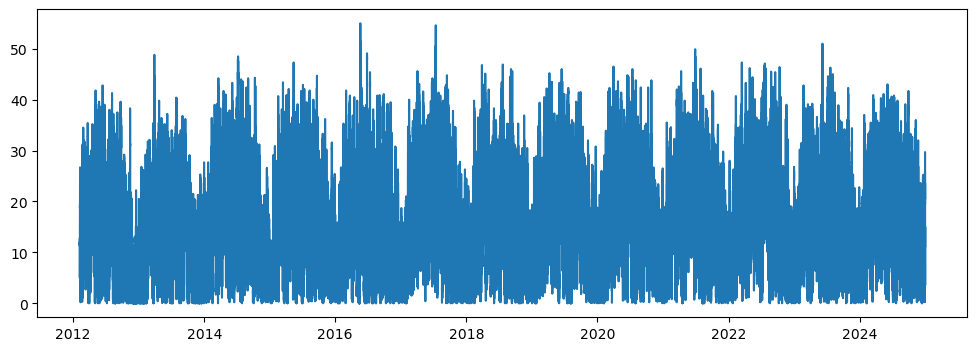

In [6]:
# plot full time series (no averaging)
fig = plt.figure(figsize=(12,4))

plt.plot(ds.time,ds.wind_speed)

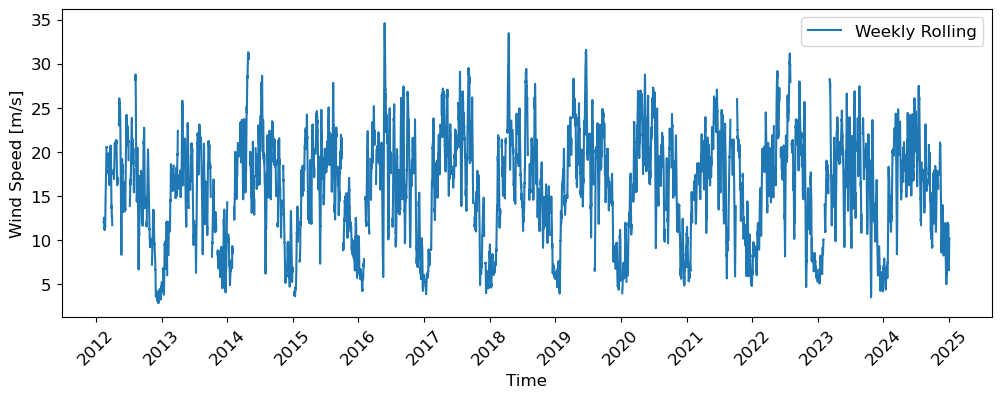

In [7]:
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize=(12,4))
plt.plot(ds.time,ds.wind_speed.rolling(time=1008).mean(),label='Weekly Rolling',linestyle='-')
#plt.plot(ds.time,ds.wind_speed.rolling(time=4032).mean(),label='Monthly Rolling')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Wind Speed [m/s]')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/wspd_timeseries_weeklyrolling.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

Low and high frequency variability is evident in the fourteen year time series of wind speed (Figure 1). Low frequency variability is illustrated by the annual cycle with wind speeds gradually rising at the start of the year as austral fall approaches. Wind speed reaches a maximum mid year in the peak of winter (JJA) and then gradually declines through spring until reaching minimum values in summer (DJF). High frequency variability surrounds the annual cycle, appearing as spikes, corresponding to changes in wind speed on shorter timescales. No trend is evident that would suggest a mean increase or decrease in wind speed since 2012, however, there are some years that have higher peaks at shorter timescales such as 2016, 2018, and 2019. 

(0.0, 0.04549211507159538)

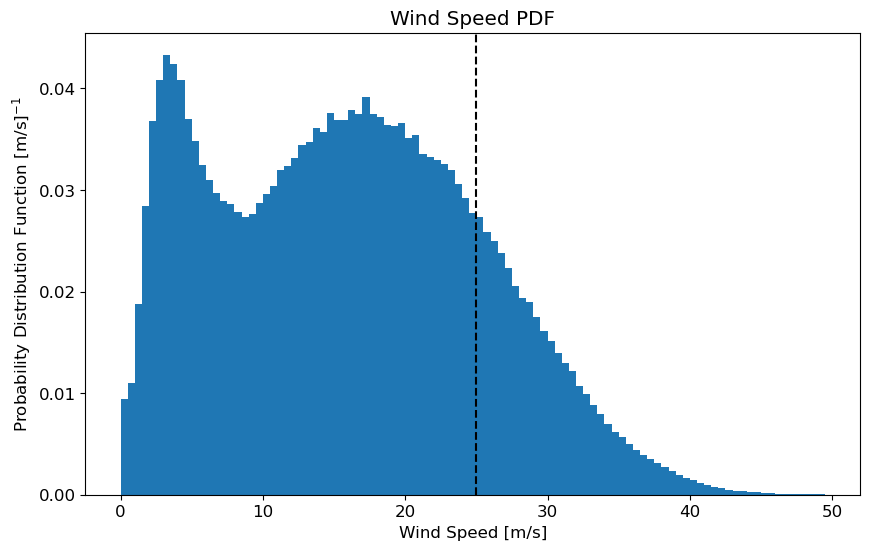

In [8]:
fig = plt.figure(figsize=(10,6))
bmin, bmax, dbins = (0,50,0.5)
bins = np.arange(bmin,bmax,dbins)
plt.hist(ds.wind_speed,density=True,bins=bins);
plt.title('Wind Speed PDF')
plt.ylabel(r'Probability Distribution Function [m/s]$^{-1}$')
plt.xlabel('Wind Speed [m/s]')
y_start, y_stop = plt.ylim()
plt.vlines(x=25,ymin=y_start,ymax=y_stop,linestyle='dashed',color='k')
plt.ylim(y_start,y_stop)

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/wspd_pdf.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

The above plot shows the probability distribution for wind speed. The PDF is characterized by two peaks one at lower wind speed (5 m/s) and one at moderate wind speeds (17 m/s). The black dashed line indicated wind speed at 25 m/s, the defining magntidue for katabatic winds. For TNB research, we are interested in wind speeds at or above this threshold. We can see that katabatic winds characterize the tail end of the distribution but still have a decent contribution to the PDF. 

### Investigate katabatic winds 
First investigate katabatic winds by using a defining threshold of 25 m/s. Data is kept at the 10 minute output and a "katabatic event" is not defined yet 

In [33]:
# define threshold for katabatic wind speed and create a mask
katabatic = ds.wind_speed > 25

In [34]:
# fraction of time 
freq = katabatic.resample(time='1M').mean()  # gives fraction of time per month
# count of katabatic winds per month 
count = katabatic.resample(time='1M').sum()


c:\Users\mblan\miniforge3\envs\TNB\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
c:\Users\mblan\miniforge3\envs\TNB\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


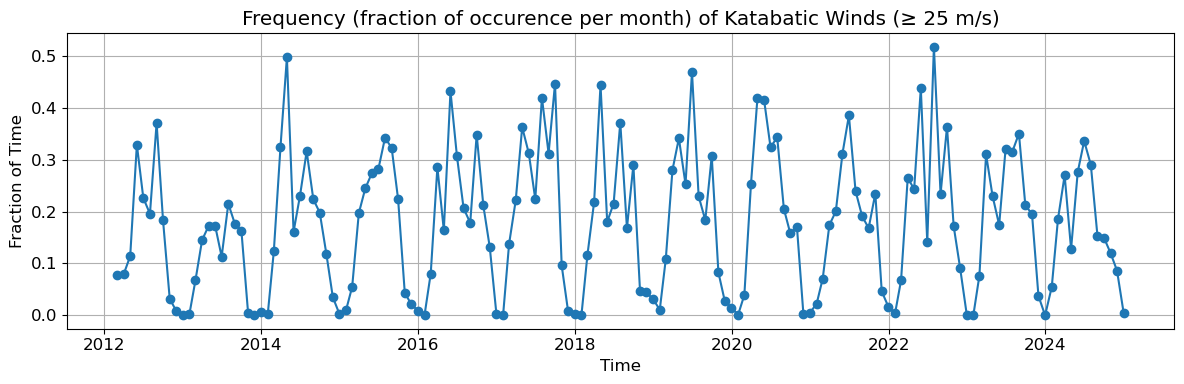

In [35]:
import matplotlib.pyplot as plt

freq.plot(marker='o',linestyle='-',figsize=(12,4))
plt.title("Frequency (fraction of occurence per month) of Katabatic Winds (≥ 25 m/s)")
plt.ylabel("Fraction of Time")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()


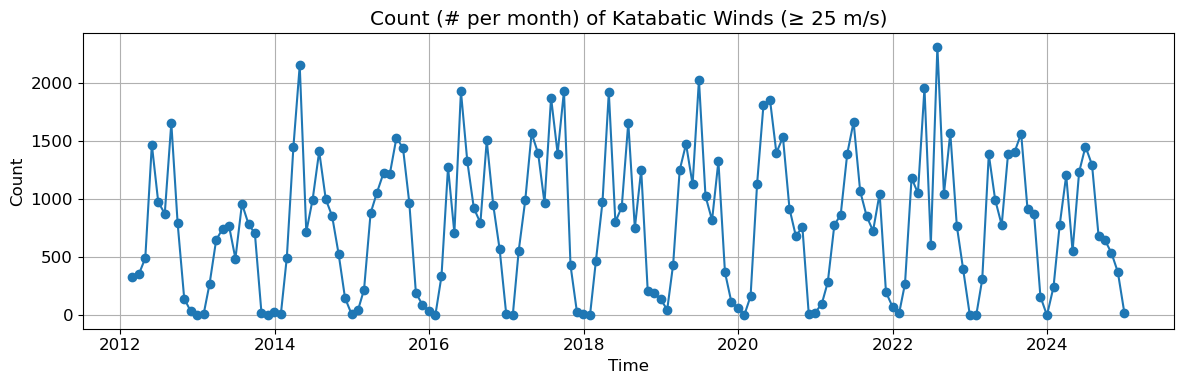

In [40]:
count.plot(marker='o',linestyle='-',figsize=(12,4))
plt.title("Count (# per month) of Katabatic Winds (≥ 25 m/s)")
plt.ylabel("Count")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

The above two plots show the frequency and occurance of katabatic wind speeds on a monthly basis. A seasonal cycle is evident, with katabatic wind occurance increasing in fall / winter months and decreasing to almost zero in summer months. 

In [41]:
# make a monthly decadal count for the 2012-2025 period 
katabatic_count_decadal = count.groupby('time.month').sum()

Text(0, 0.5, 'Katabatic Wind Count')

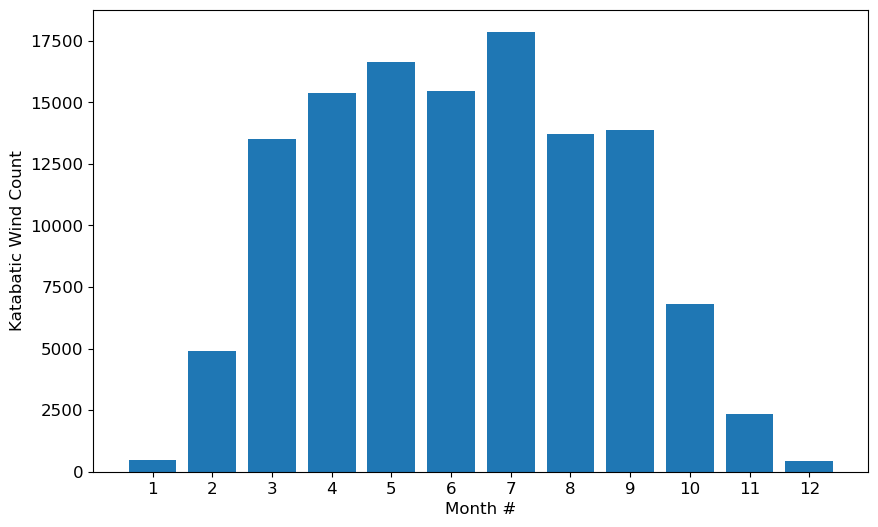

In [42]:
fig = plt.figure(figsize=(10,6))
plt.bar(katabatic_count_decadal.month,katabatic_count_decadal)
plt.xticks(np.arange(1,13,1));
plt.xlabel('Month #')
plt.ylabel('Katabatic Wind Count')

We can see that July has the highest occurance of katabatic winds from the years 2012-2025 

In [43]:
# calculate katabatic count anomaly 
katabatic_count_anomaly = katabatic.resample(time='1M').sum().groupby('time.month') - count.groupby('time.month').mean()

c:\Users\mblan\miniforge3\envs\TNB\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


Text(0, 0.5, 'Katabatic Count Monthly Anomaly')

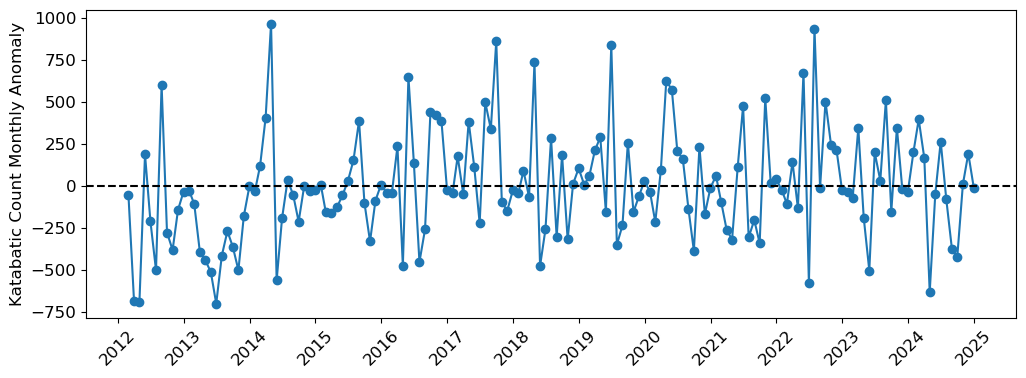

In [44]:
fig = plt.figure(figsize=(12,4))
plt.plot(katabatic_count_anomaly.time,katabatic_count_anomaly,linestyle='-',marker='o')
# Get start and end of x-axis in datetime
x_start, x_end = plt.xlim()
plt.xlim(x_start,x_end)

plt.hlines(y=0,xmin=x_start, xmax=x_end,color='k',linestyle='dashed')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);

plt.ylabel('Katabatic Count Monthly Anomaly')


### Define Katabatic Events 

We are intersted in katabatic wind events that trigger a polynya opening / sea ice production / HSSW production. We define a katabatic wind event as one where winds speed are equal to or greater than 25 m/s for at least one hour. 

In [45]:
import xarray as xr
import numpy as np
from scipy.ndimage import label

def extract_katabatic_segments(wind, threshold=25, min_duration=6):
    """
    Return a single DataArray with katabatic wind events labeled by 'event',
    retaining the time coordinate for filtering.
    """

    # define mask based on wind speed threshold 
    mask = wind >= threshold
    labeled, num_labels = label(mask.values)

    # initiate empty lists
    event_list = []
    time_list = []
    event_id_list = []

    # loop through numbered labels to create mask 
    for label_id in range(1, num_labels + 1):
        region_mask = (labeled == label_id)
    # identify if region mask sums up to 6 (i.e. 1 hour: 6 x 10 minute timestep)
        # if yes, create a data array segment based on region mask and append to empty lists 
        if region_mask.sum() >= min_duration:
            region_mask_da = xr.DataArray(region_mask, coords={"time": wind.time}, dims="time")
            segment = wind.where(region_mask_da, drop=True)
            
            event_list.append(segment.values)
            time_list.append(segment.time.values)
            event_id_list.append(np.full(segment.time.shape, label_id))

    if not event_list:
        return None

    # Flatten all event time series into one
    all_values = np.concatenate(event_list)
    all_times = np.concatenate(time_list)
    all_events = np.concatenate(event_id_list)

    # Create final DataArray with 'time' and 'event' as coordinates
    katabatic = xr.DataArray(
        all_values,
        coords={
            "time": all_times,
            "event": ("time", all_events)
        },
        dims="time",
        name="katabatic_wind"
    )

    return katabatic


In [46]:
# apply function to wind speed data to create katabatic events 
segments = extract_katabatic_segments(wind=ds.wind_speed)

In [47]:
segments 

<xarray.DataArray 'katabatic_wind' (time: 109870)> Size: 879kB
array([25. , 25.4, 26.3, ..., 25.7, 25.4, 25.1], shape=(109870,))
Coordinates:
  * time     (time) datetime64[ns] 879kB 2012-02-08T11:20:00 ... 2024-11-22T2...
    event    (time) int64 879kB 1 1 1 1 1 1 1 ... 9826 9826 9826 9826 9826 9826

In [48]:
# seperate the katabatic events into seasons based on numbered months 
summer_segments = segments.loc[segments['time.month'].isin([12,1,2])]
fall_segments = segments.loc[segments['time.month'].isin([3,4,5])]
winter_segments = segments.loc[segments['time.month'].isin([6,7,8])]
spring_segments = segments.loc[segments['time.month'].isin([9,10,11])]

Text(0.5, 1.0, 'Spring')

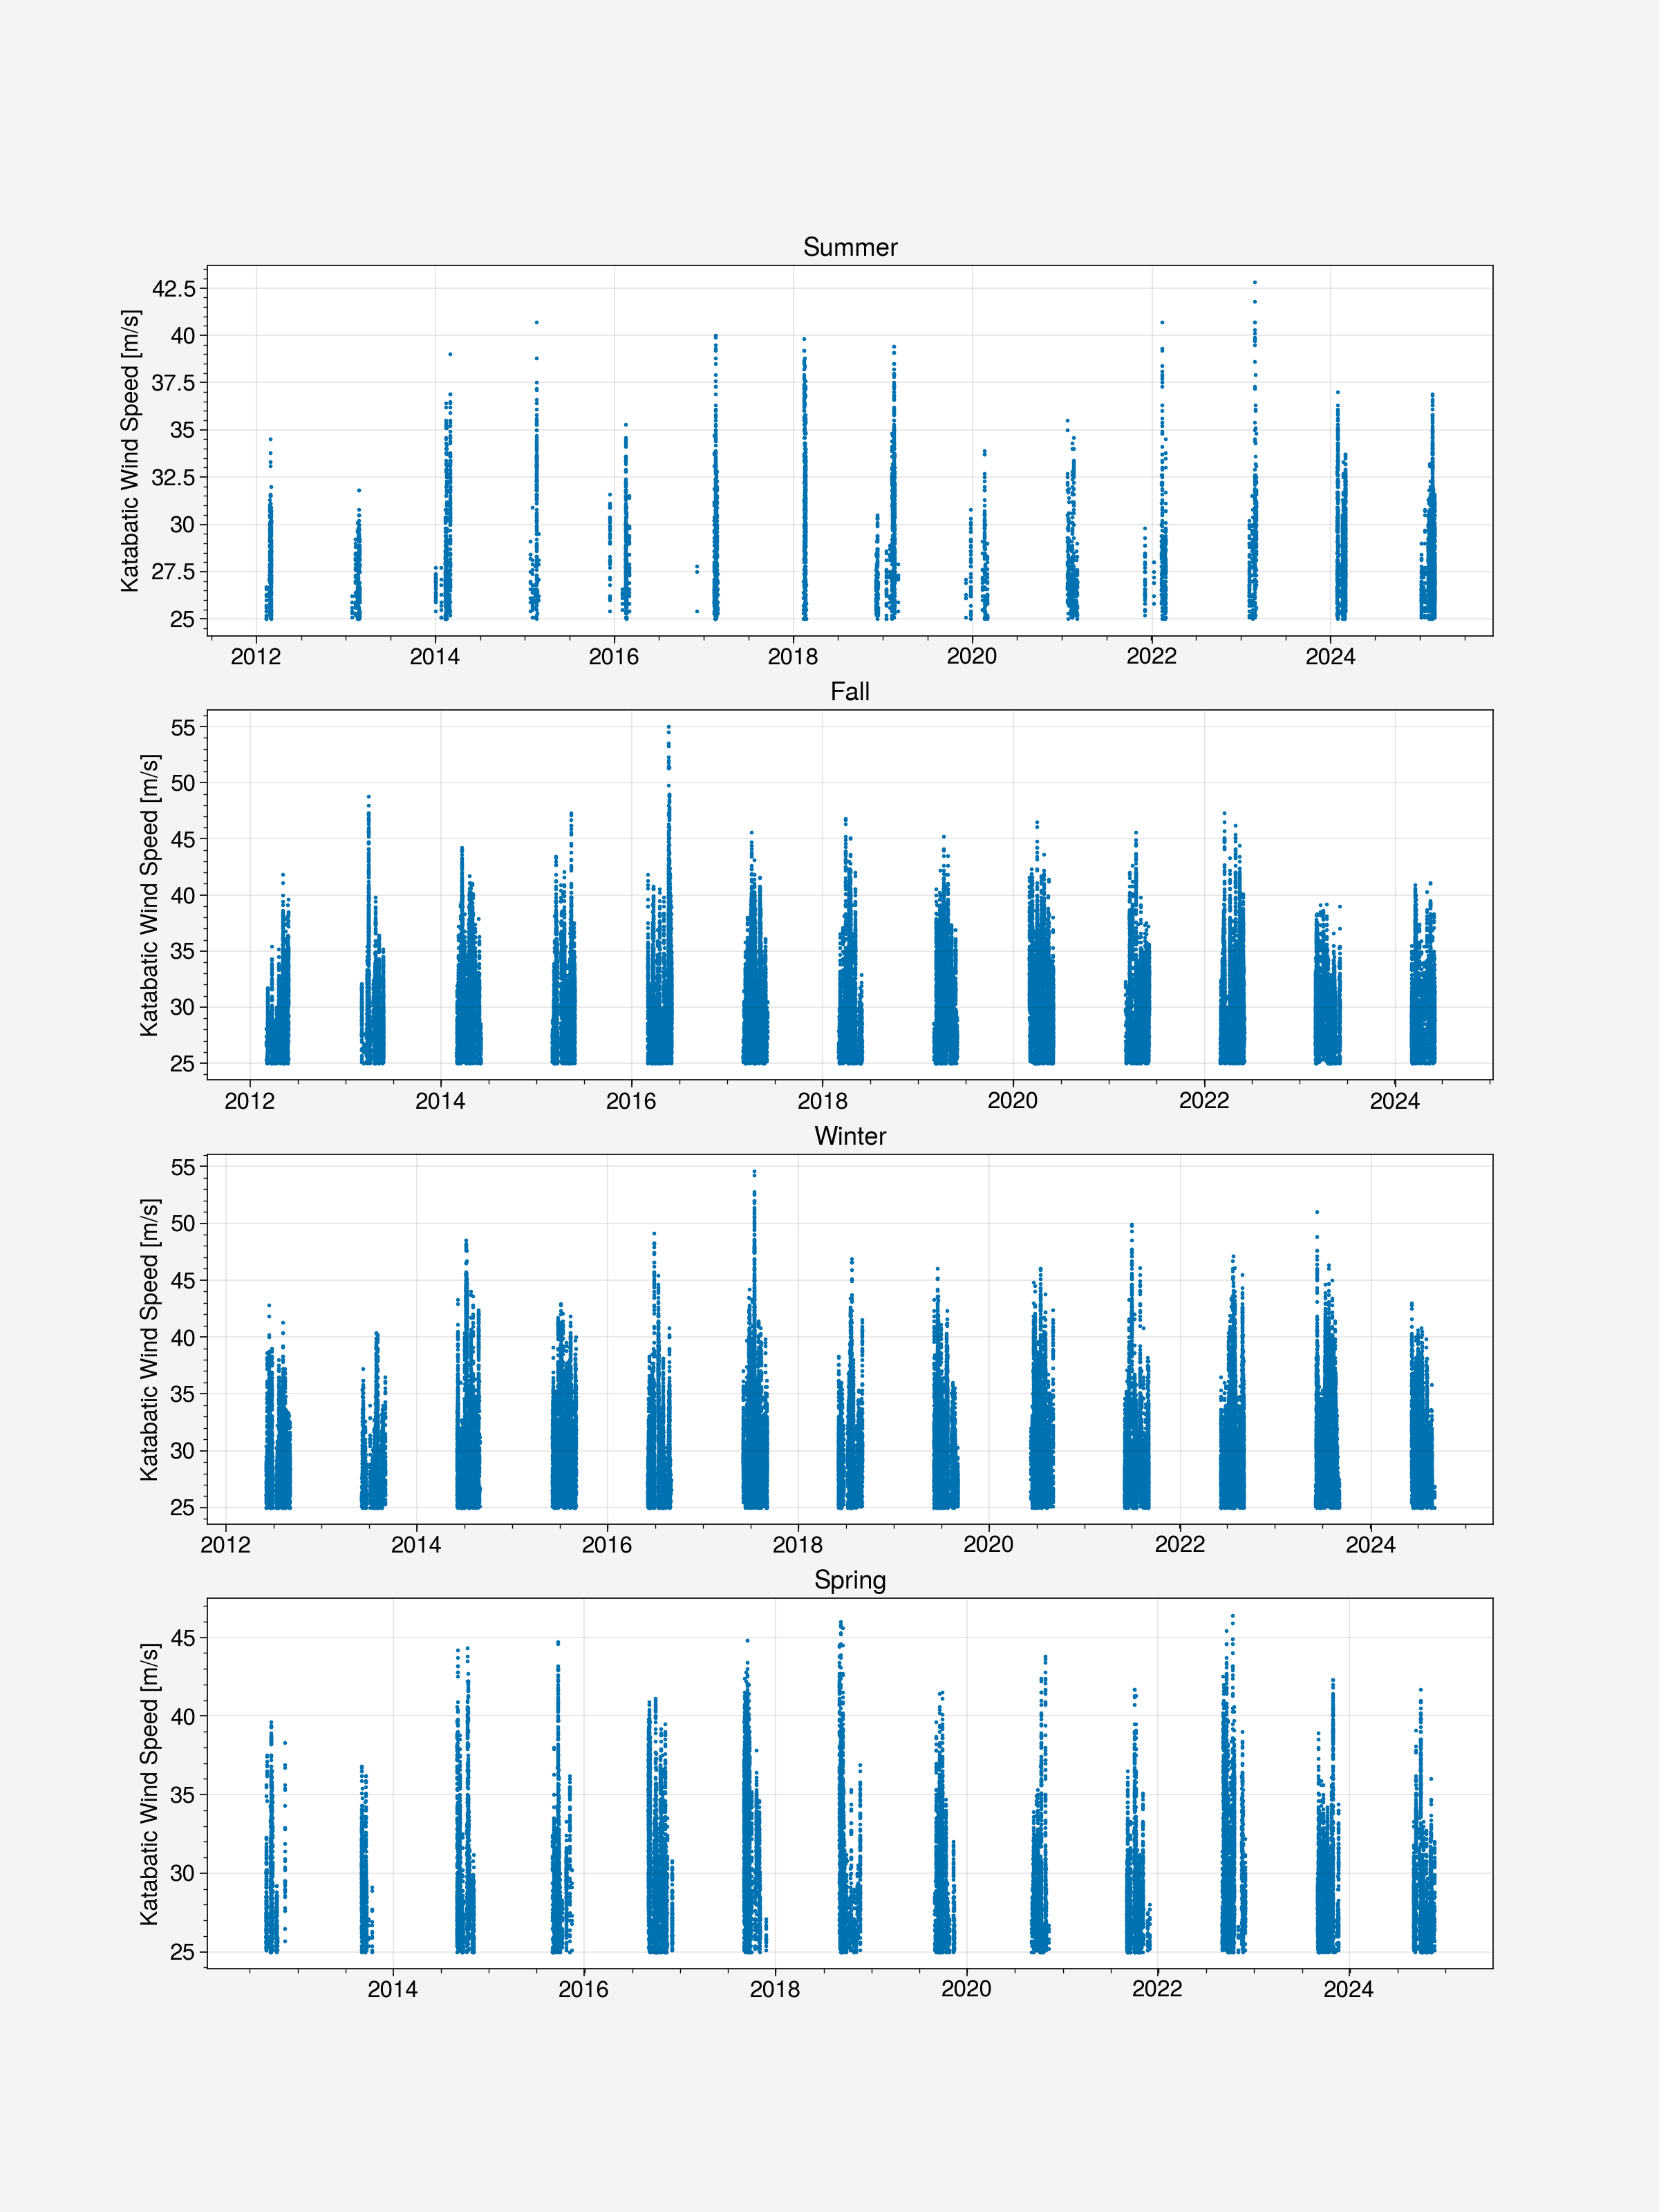

In [55]:
# plot katabatic wind events by season 
fig = plt.figure(figsize=(12,16))
plt.subplot(4,1,1)
plt.scatter(summer_segments.time,summer_segments,s=2)
plt.ylabel('Katabatic Wind Speed [m/s]')
plt.title('Summer')


plt.subplot(4,1,2)
plt.scatter(fall_segments.time,fall_segments,s=2)
plt.ylabel('Katabatic Wind Speed [m/s]')
plt.title('Fall')

plt.subplot(4,1,3)
plt.scatter(winter_segments.time,winter_segments,s=2)
plt.ylabel('Katabatic Wind Speed [m/s]')
plt.title('Winter')

plt.subplot(4,1,4)
plt.scatter(spring_segments.time,spring_segments,s=2)
plt.ylabel('Katabatic Wind Speed [m/s]')
plt.title('Spring')

In [56]:
# calculate seasonal counts of katabatic wind events 
# for loop to get useful info per year

winter_count = [] 
years = np.arange(2012,2026,1)
for i in range(len(years)):
    # select year 
    if i == range(len(years))[-1]:
        winter_count.append(np.nan)
    else:
        subset = winter_segments.sel(time=str(years[i]))
        winter_count.append(len(np.unique(subset.event)))

spring_count = [] 
years = np.arange(2012,2026,1)
for i in range(len(years)):
    # select year 
    if i == range(len(years))[-1]:
        spring_count.append(np.nan)
    else:
        subset = spring_segments.sel(time=str(years[i]))
        spring_count.append(len(np.unique(subset.event)))

fall_count = [] 
years = np.arange(2012,2026,1)
for i in range(len(years)):
    # select year 
    if i == range(len(years))[-1]:
        fall_count.append(np.nan)
    else:
        subset = fall_segments.sel(time=str(years[i]))
        fall_count.append(len(np.unique(subset.event)))

In [57]:
fall_count

[62, 53, 82, 73, 78, 83, 100, 84, 96, 82, 89, 91, 70, nan]

In [58]:
winter_count

[105, 77, 80, 104, 82, 106, 114, 80, 95, 121, 109, 100, 93, nan]

In [59]:
spring_count

[27, 24, 48, 36, 78, 50, 50, 54, 46, 82, 62, 46, 53, nan]

In [60]:
summer_count = [] 
years = np.arange(2012,2026,1)
for i in range(len(years)):
    # select year 
    if i == 0: 
        subset = summer_segments.sel(time=str(years[i]))
        summer_count.append(len(np.unique(subset.event)))

    elif i == range(len(years))[-1]:
        subset = summer_segments.sel(time=str(years[i]))
        summer_count.append(len(np.unique(subset.event)))
    else:
        year = summer_segments.loc[summer_segments['time.year'].isin(years[i])]
        dec_contribution = len(np.unique(year.loc[year['time.month'].isin([12])].event))

        year = summer_segments.loc[summer_segments['time.year'].isin(years[i+1])]
        feb_jan_contribution = len(np.unique(year.loc[year['time.month'].isin([1,2])].event))

        summer_count.append(np.sum([dec_contribution,feb_jan_contribution]))

In [61]:
summer_count

[16, 22, 8, 9, 19, 10, 14, 11, 19, 14, 8, 27, 35, 35]

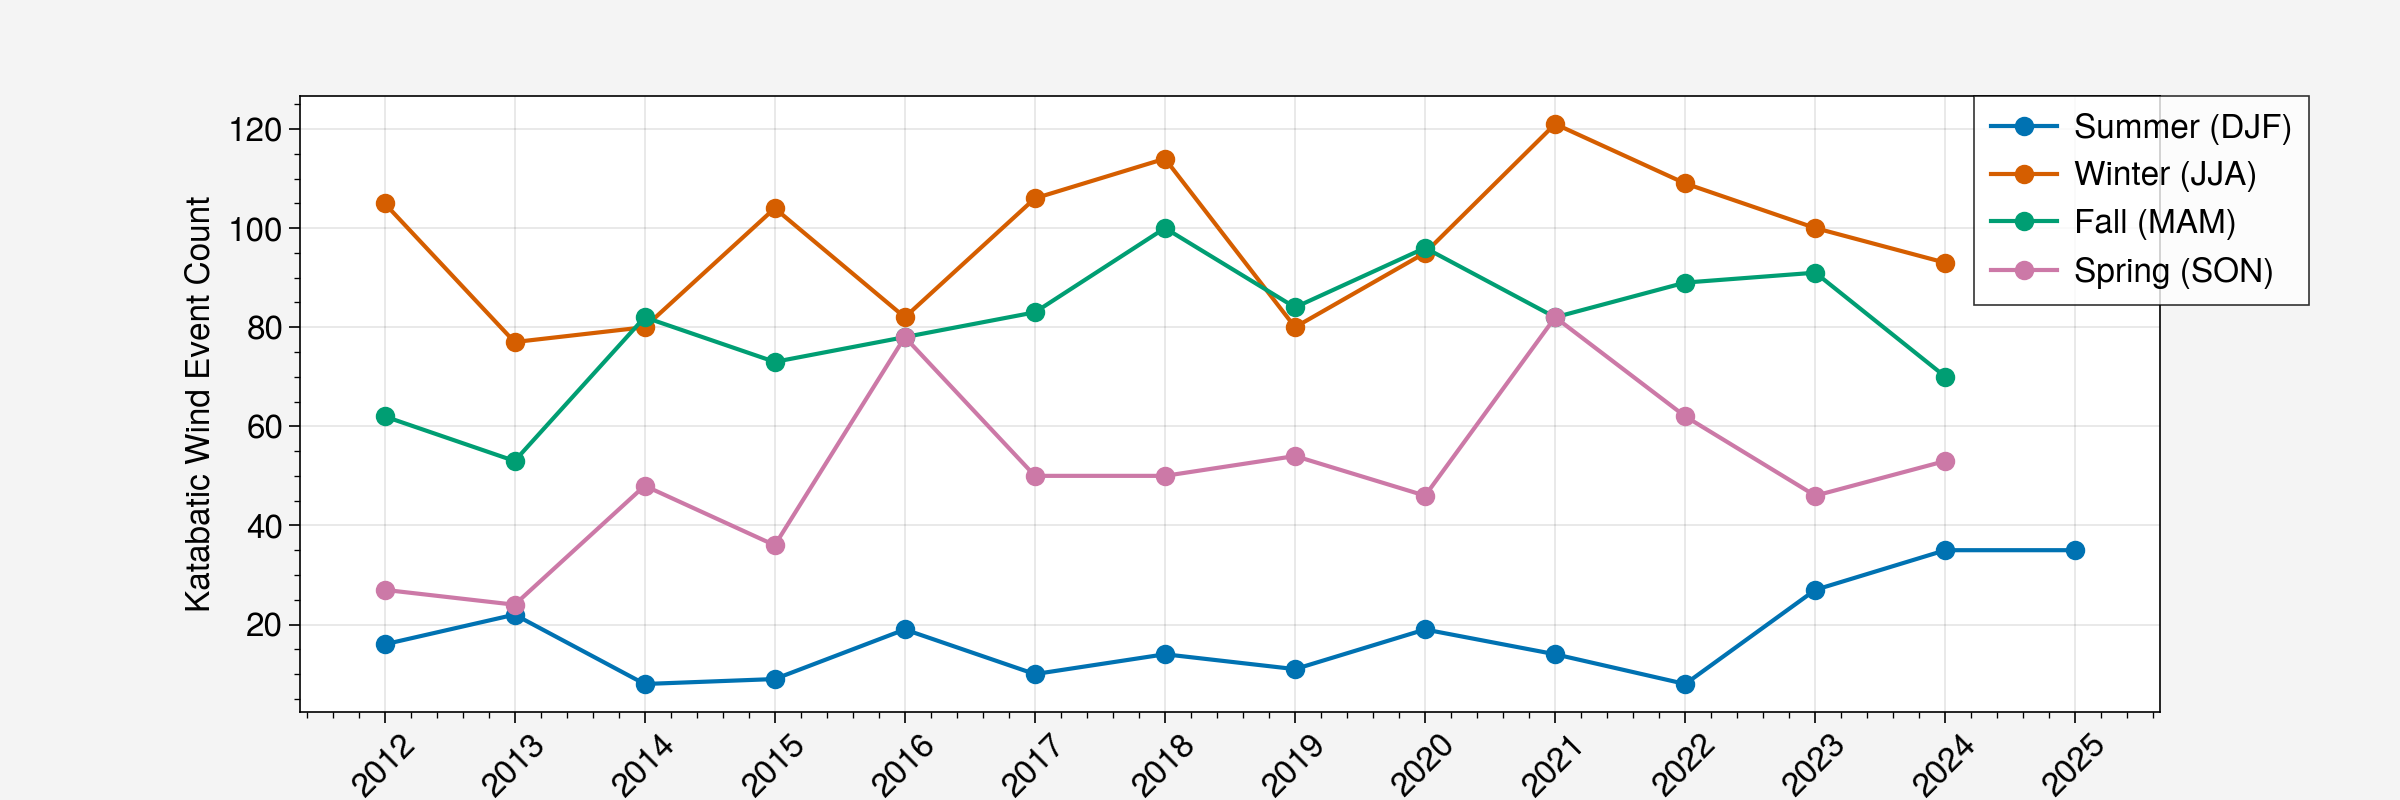

In [62]:
# plot katabatic wind event count per season 
fig = plt.figure(figsize=(12,4))
plt.plot(years,summer_count,label='Summer (DJF)',linestyle='-',marker='o')
plt.plot(years,winter_count, label='Winter (JJA)',linestyle='-',marker='o')
plt.plot(years,fall_count, label='Fall (MAM)',linestyle='-',marker='o')
plt.plot(years,spring_count,label='Spring (SON)',linestyle='-',marker='o')
plt.xticks(years,rotation=45);
plt.ylabel('Katabatic Wind Event Count')
plt.legend(bbox_to_anchor=(0.9, 1), loc='upper left')

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/katabatic_count_seasonal.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

Important to note here that summer does indeed have katabatic wind events. I should look into whether these events actually produce any HSSW - would need to figure out if any ice is produced during these summer events. Perhaps during early summer before the polynya is completely open. 

In [63]:
# how many katabatic wind events for each year? 
# average duration of each katabatic wind event per year?
# max duration of katabatic wind event per year? 
# mean wind speed in katabatic events per year? 
# max wind speed in katabatic events per year? 
# what month has the most katabatic wind events per year? 

# initiate empty lists 
events_per_year = [] 
mean_event_duration = []
max_event_duration = []
mean_wind_speed = []
max_wind_speed = []
years = np.arange(2012,2026,1)

# for loop to get useful info per year
for i in range(len(years)):
    # select year 
    subset = segments.sel(time=str(years[i]))
    # mean wind speed per year 
    mean_wind_speed.append(subset.mean().values)
    # max wind speed per year 
    max_wind_speed.append(subset.max().values)
    # number of katabatic wind events per year 
    events_per_year.append(len(np.unique(subset.event)))
    # initiate empty list 
    event_duration = []
    # loop through individual events in one year 
    for i in range(len(np.unique(subset.event))):
        # select one event 
        event = subset.where(subset.event == np.unique(subset.event)[i],drop=True)
        # calculate event duration and add to list 
        event_duration.append(np.sum(np.diff(event.time))/np.timedelta64(1, 'h'))   # convert ns to hours
    # mean event duration per year 
    mean_event_duration.append(np.mean(event_duration))
    # max event duration per year 
    max_event_duration.append(np.max(event_duration))
    

Text(0, 0.5, 'Max Event Duration [hrs]')

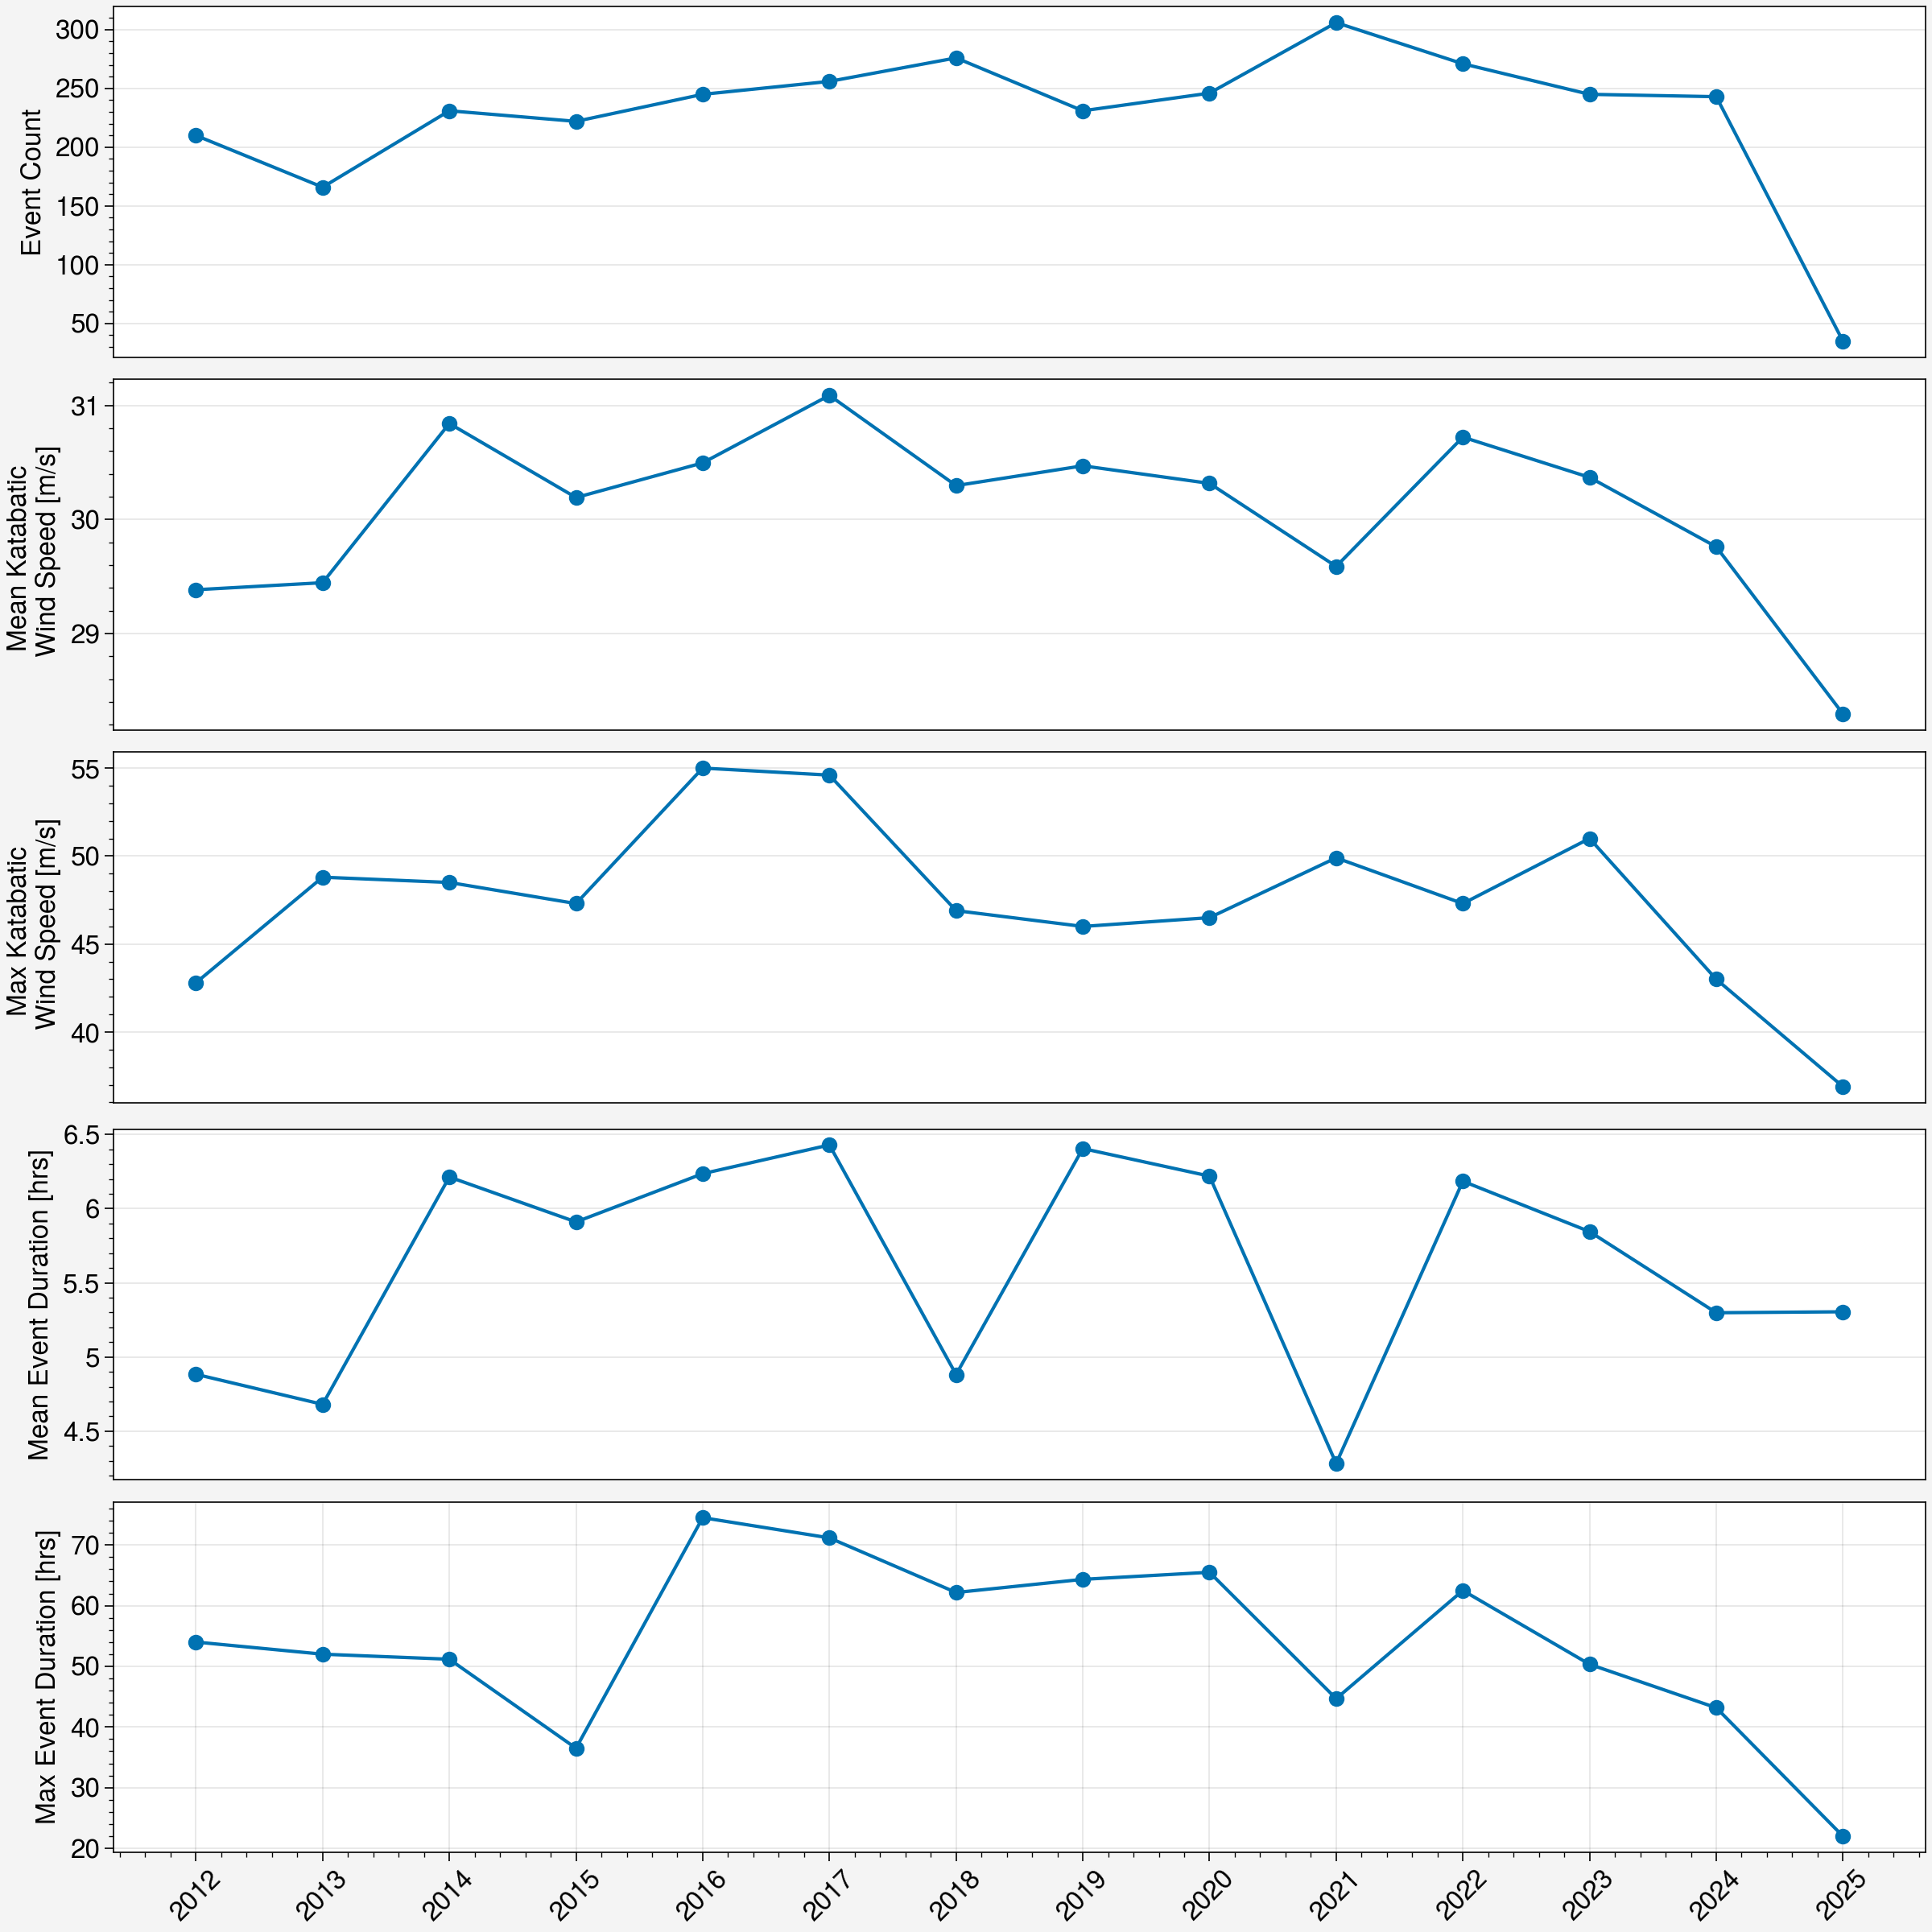

In [64]:
# plot of above calculated quantities 
fig = plt.figure(figsize=(12,12),constrained_layout=True)
plt.subplot(5,1,1)
plt.plot(years,events_per_year,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks([]);
plt.ylabel('Event Count')

plt.subplot(5,1,2)
plt.plot(years,mean_wind_speed,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks([]);
plt.ylabel('Mean Katabatic \n Wind Speed [m/s]')

plt.subplot(5,1,3)
plt.plot(years,max_wind_speed,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks([]);
plt.ylabel('Max Katabatic \n Wind Speed [m/s]')

plt.subplot(5,1,4)
plt.plot(years,mean_event_duration,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks([]);
plt.ylabel('Mean Event Duration [hrs]')

plt.subplot(5,1,5)
plt.plot(years,max_event_duration,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks(years,rotation=45);
plt.ylabel('Max Event Duration [hrs]')

# plt.savefig('katabatic_wind_info.png')
# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/katabatic_yearly_info.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

This last figure provides a lot of useful information on katabatic wind events. We can see that mean katabatic wind duration ranges from approx 4-6.5 hours, but max event durations can last up to 60-70 hours in extreme cases. Mean wind speeds are around 30 m/s, while max wind speeds can reach 55 m/s. 2021 has the record for the most katabatic wind events. It's interesting that this year also has the lowest mean event duration and low mean wind speed compared to other years. This suggests that 2021 may have been characterized by katabatic wind events that had burst like activity. 

### Monthly Anomalies - Wind Speed 

In [9]:
ds

<xarray.Dataset> Size: 43MB
Dimensions:            (time: 679392)
Coordinates:
  * time               (time) datetime64[ns] 5MB 2012-02-01 ... 2024-12-31T23...
    index              (time) float64 5MB ...
Data variables:
    temp               (time) float64 5MB ...
    pressure           (time) float64 5MB ...
    wind_speed         (time) float64 5MB nan nan nan nan ... 12.9 11.3 nan nan
    wind_dir           (time) float64 5MB ...
    relative_humidity  (time) float64 5MB ...
    delta-temp         (time) float64 5MB ...

In [10]:
# 1. Monthly mean time series from 10-minute data
ds_mon = ds.resample(time='MS').mean()
# 'MS' = month start; use 'M' if you prefer month end labels

# 2. Monthly climatology over 2012-2024
wind_speed_clim = ds_mon['wind_speed'].groupby('time.month').mean('time')

# 3. Monthly anomalies
wind_speed_anom = ds_mon['wind_speed'].groupby('time.month') - wind_speed_clim

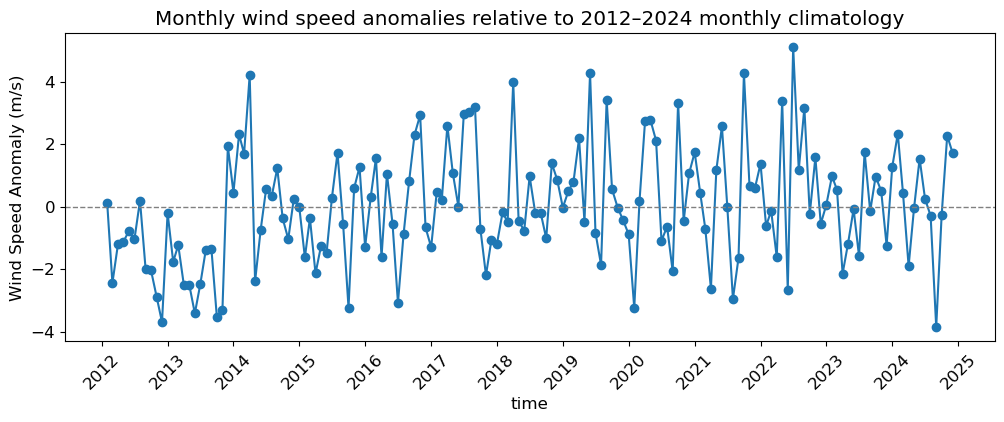

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
wind_speed_anom.plot(ax=ax,marker='o')
ax.axhline(0, color='grey', lw=1, linestyle='dashed')
ax.set_ylabel('Wind Speed Anomaly (m/s)')
ax.set_title('Monthly wind speed anomalies relative to 2012–2024 monthly climatology')
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);
plt.show()

In [12]:
# seasonal anomalies 
# selecting data starting in March 2012 to allow creation of whole season from the start 
ds_seas = ds.sel(time=slice('2012-03',None)).resample(time='QS-DEC').mean()
# QS-DEC makes DJF, MAM, JJA, SON seasons starting in Dec

wind_speed_seasonal_clim = ds_seas['wind_speed'].groupby('time.season').mean('time')
wind_speed_seasonal_anom = ds_seas['wind_speed'].groupby('time.season') - wind_speed_seasonal_clim

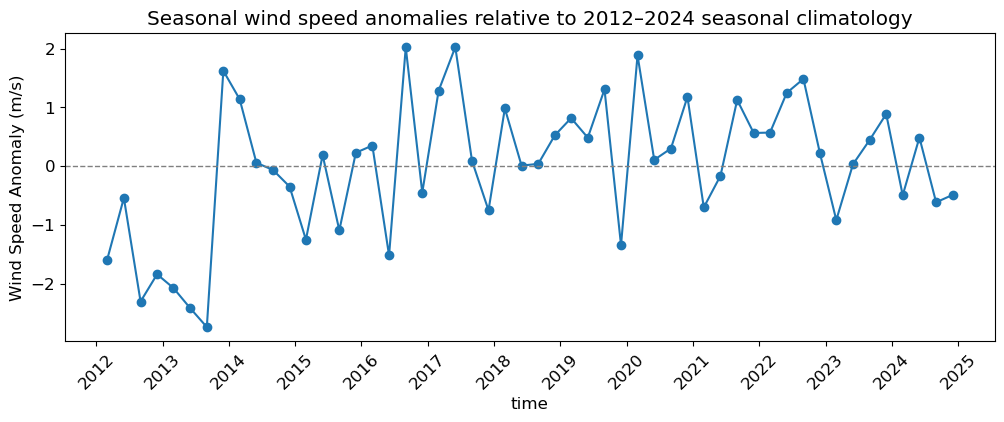

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
wind_speed_seasonal_anom.plot(ax=ax,marker='o')
ax.axhline(0, color='grey', lw=1, linestyle='dashed')
ax.set_ylabel('Wind Speed Anomaly (m/s)')
ax.set_title('Seasonal wind speed anomalies relative to 2012–2024 seasonal climatology')
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);
plt.show()

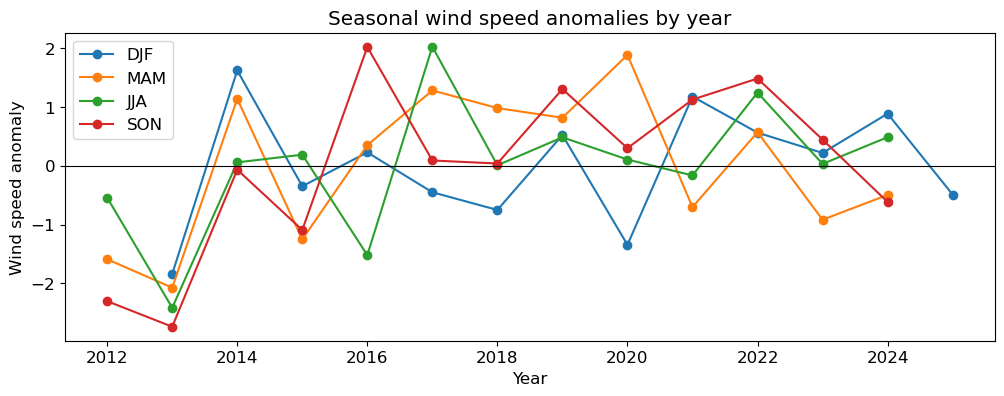

In [51]:
da = wind_speed_seasonal_anom

season_year = xr.where(
    da.time.dt.month == 12,
    da.time.dt.year + 1,
    da.time.dt.year
)

da = da.assign_coords(
    season=("time", da.time.dt.season.data),
    season_year=("time", season_year.data)
)

DJF = da.where(da.season == "DJF", drop=True).groupby("season_year").mean()
MAM = da.where(da.season == "MAM", drop=True).groupby("season_year").mean()
JJA = da.where(da.season == "JJA", drop=True).groupby("season_year").mean()
SON = da.where(da.season == "SON", drop=True).groupby("season_year").mean()

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(DJF.season_year, DJF, marker="o", label="DJF")
ax.plot(MAM.season_year, MAM, marker="o", label="MAM")
ax.plot(JJA.season_year, JJA, marker="o", label="JJA")
ax.plot(SON.season_year, SON, marker="o", label="SON")

ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Wind speed anomaly")
ax.set_title("Seasonal wind speed anomalies by year")
ax.legend()


plt.show()

In [23]:
anom_2d = wind_speed_anom.assign_coords(
    year=wind_speed_anom['time'].dt.year,
    month=wind_speed_anom['time'].dt.month
).set_index(time=['year', 'month']).unstack('time')

In [24]:
anom_2d

<xarray.DataArray 'wind_speed' (year: 13, month: 12)> Size: 1kB
array([[            nan,  1.25315302e-01, -2.44599448e+00,
        -1.19431122e+00, -1.12019940e+00, -7.76583360e-01,
        -1.04962854e+00,  1.94402119e-01, -1.99663795e+00,
        -2.03734076e+00, -2.88800443e+00, -3.69836778e+00],
       [-2.01831710e-01, -1.76564000e+00, -1.23267577e+00,
        -2.50500103e+00, -2.49870680e+00, -3.41740266e+00,
        -2.49002628e+00, -1.37444593e+00, -1.35866620e+00,
        -3.53028811e+00, -3.30314332e+00,  1.93133863e+00],
       [ 4.51322503e-01,  2.31617901e+00,  1.69544307e+00,
         4.21297025e+00, -2.39082107e+00, -7.38058278e-01,
         5.60028679e-01,  3.27500504e-01,  1.23050954e+00,
        -3.77961561e-01, -1.03947434e+00,  2.32477960e-01],
       [-1.25130774e-02, -1.62655712e+00, -3.71716431e-01,
        -2.13800189e+00, -1.27556882e+00, -1.49907615e+00,
         2.87526438e-01,  1.72496914e+00, -5.58888568e-01,
        -3.23871258e+00,  5.92863621e-01,  1.26658024e+00],
       [-1.28834698e+00,  3.04457776e-01,  1.55068252e+00,
        -1.61129997e+00,  1.05176093e+00, -5.54228131e-01,
        -3.08556944e+00, -8.90375841e-01,  8.24275973e-01,
         2.30267407e+00,  2.93252797e+00, -6.66513873e-01],
...
       [-8.84619697e-01, -3.24721887e+00,  1.67788498e-01,
         2.75571391e+00,  2.76701631e+00,  2.11489311e+00,
        -1.09296152e+00, -6.37724730e-01, -2.06577433e+00,
         3.32544513e+00, -4.59289157e-01,  1.06259279e+00],
       [ 1.74146407e+00,  4.25209026e-01, -7.10202094e-01,
        -2.62575599e+00,  1.16597464e+00,  2.56929126e+00,
        -1.94852103e-02, -2.95480232e+00, -1.64188690e+00,
         4.27093576e+00,  6.49692325e-01,  5.92554707e-01],
       [ 1.37446877e+00, -6.23048769e-01, -1.28705678e-01,
        -1.61909320e+00,  3.39207088e+00, -2.66834763e+00,
         5.11067074e+00,  1.17552482e+00,  3.16753986e+00,
        -2.31118491e-01,  1.57684574e+00, -5.49664220e-01],
       [ 6.46799240e-02,  9.76827162e-01,  5.39394680e-01,
        -2.14590646e+00, -1.18659032e+00, -7.64842043e-02,
        -1.57917035e+00,  1.74851384e+00, -1.47136064e-01,
         9.64457226e-01,  5.03252319e-01, -1.24569574e+00],
       [ 1.26459036e+00,  2.33443382e+00,  4.22369591e-01,
        -1.90500368e+00, -4.96167545e-02,  1.53633987e+00,
         2.51997027e-01, -2.92960508e-01, -3.85556199e+00,
        -2.79142665e-01,  2.27597749e+00,  1.71359995e+00]])
Coordinates:
  * year     (year) int64 104B 2012 2013 2014 2015 2016 ... 2021 2022 2023 2024
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [25]:
ws_2d = ds_mon['wind_speed'].assign_coords(
    year=ds_mon.time.dt.year,
    month=ds_mon.time.dt.month
).set_index(time=['year', 'month']).unstack('time')

In [26]:
ws_2d

<xarray.DataArray 'wind_speed' (year: 13, month: 12)> Size: 1kB
array([[        nan, 15.17119285, 16.67277616, 19.04141005, 18.43453608,
        18.67388233, 18.39508068, 17.8494061 , 16.6018407 , 13.21188929,
         8.13791667,  3.93600403],
       [ 7.37094352, 13.28023755, 17.88609487, 17.73072024, 17.05602869,
        16.03306302, 16.95468295, 16.28055805, 17.23981246, 11.71894194,
         7.72277778,  9.56571044],
       [ 8.02409774, 17.36205656, 20.81421371, 24.44869152, 17.16391441,
        18.71240741, 20.0047379 , 17.98250448, 19.82898819, 14.87126849,
         9.98644676,  7.86684978],
       [ 7.56026216, 13.41932044, 18.74705421, 18.09771938, 18.27916667,
        17.95138953, 19.73223566, 19.37997312, 18.03959009, 12.01051747,
        11.61878472,  8.90095206],
       [ 6.28442825, 15.35033533, 20.66945316, 18.6244213 , 20.60649642,
        18.89623755, 16.35913978, 16.76462814, 19.42275463, 17.55190412,
        13.95844907,  6.96785794],
       [ 6.27390769, 15.5108631 , 19.33015019, 22.83461806, 20.63577992,
        19.45421296, 22.41140488, 20.70183692, 21.80122742, 14.54138665,
         8.82822562,  6.56831317],
       [ 6.38978495, 14.86006203, 18.62847378, 24.22536467, 19.09982063,
        18.68188657, 20.41600941, 17.45431228, 18.38199074, 14.23248208,
        12.41052327,  8.49314363],
       [ 7.54541891, 15.54675019, 19.91130406, 22.42287037, 19.07328629,
        23.7249537 , 18.61333184, 15.78826165, 22.01444444, 15.8048734 ,
        10.9977662 ,  7.20275599],
       [ 6.68815554, 11.79865868, 19.28655914, 22.99143519, 22.32175179,
        21.5653588 , 18.3517477 , 17.01727925, 16.53270433, 18.57467518,
        10.56663194,  8.69696461],
       [ 9.3142393 , 15.47108658, 18.40856855, 17.60996528, 20.72071013,
        22.01975694, 19.42522401, 14.70020166, 16.95659175, 19.52016581,
        11.67561343,  8.22692652],
       [ 8.94724401, 14.42282878, 18.99006496, 18.61662807, 22.94680636,
        16.78211806, 24.55537996, 18.83052879, 21.76601852, 15.01811156,
        12.60276684,  7.0847076 ],
       [ 7.63745516, 16.02270471, 19.65816532, 18.08981481, 18.36814516,
        19.37398148, 17.86553888, 19.40351781, 18.45134259, 16.21368728,
        11.52917342,  6.38867608],
       [ 8.83736559, 17.38031138, 19.54114023, 18.33071759, 19.50511873,
        20.98680556, 19.69670625, 17.36204347, 14.74291667, 14.97008739,
        13.30189859,  9.34797176]])
Coordinates:
  * year     (year) int64 104B 2012 2013 2014 2015 2016 ... 2021 2022 2023 2024
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

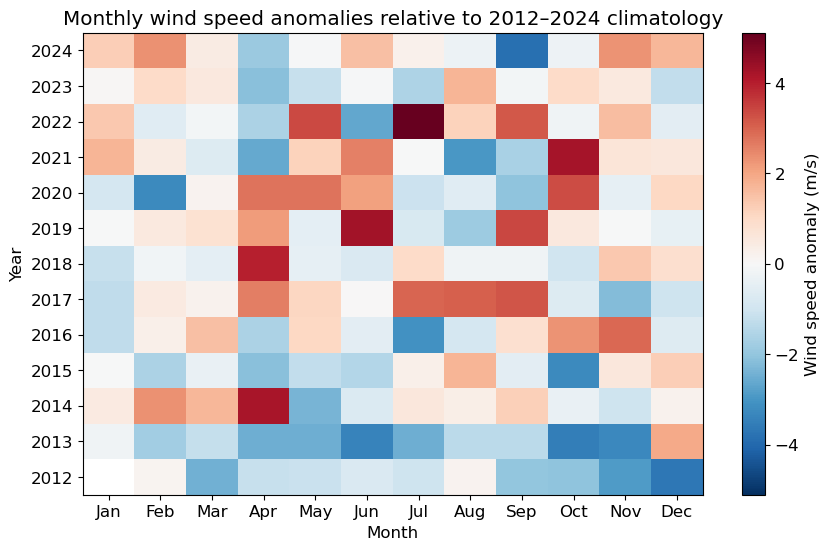

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

anom_2d.plot(
    ax=ax,
    x='month',
    y='year',
    cmap='RdBu_r',
    center=0,
    cbar_kwargs={'label': 'Wind speed anomaly (m/s)'}
)

# --- Force all years to show ---
years = anom_2d.year.values
ax.set_yticks(years)
ax.set_yticklabels(years)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])

ax.set_title('Monthly wind speed anomalies relative to 2012–2024 climatology')
ax.set_xlabel('Month')
ax.set_ylabel('Year')


plt.show()

### Box plots 

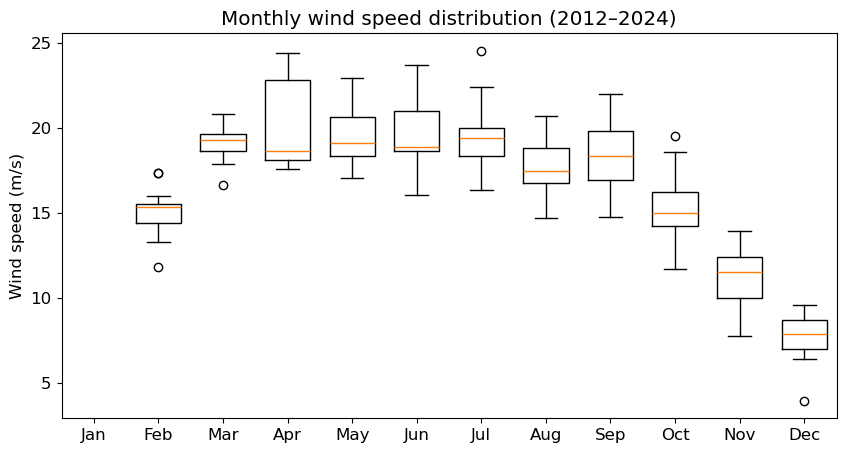

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

data = [ws_2d.sel(month=m).values for m in range(1, 13)]

bp = ax.boxplot(
    data,
    widths=0.7,
    showfliers=True
)

# ax.axhline(0, color='k', lw=0.8, zorder=0)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Wind speed (m/s)')
ax.set_title('Monthly wind speed distribution (2012–2024)')

plt.show()

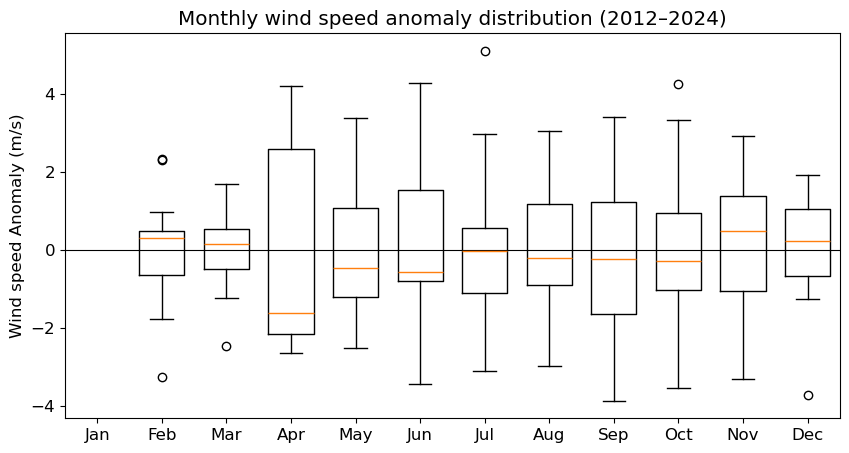

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

data = [anom_2d.sel(month=m).values for m in range(1, 13)]

bp = ax.boxplot(
    data,
    widths=0.7,
    showfliers=True
)

ax.axhline(0, color='k', lw=0.8, zorder=0)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Wind speed Anomaly (m/s)')
ax.set_title('Monthly wind speed anomaly distribution (2012–2024)')

plt.show()

### Yearly Climatology + Individual Years 

In [30]:
ws_clim = ds_mon['wind_speed'].groupby('time.month').mean('time')

In [31]:
ws_std = ds_mon['wind_speed'].groupby('time.month').std('time')

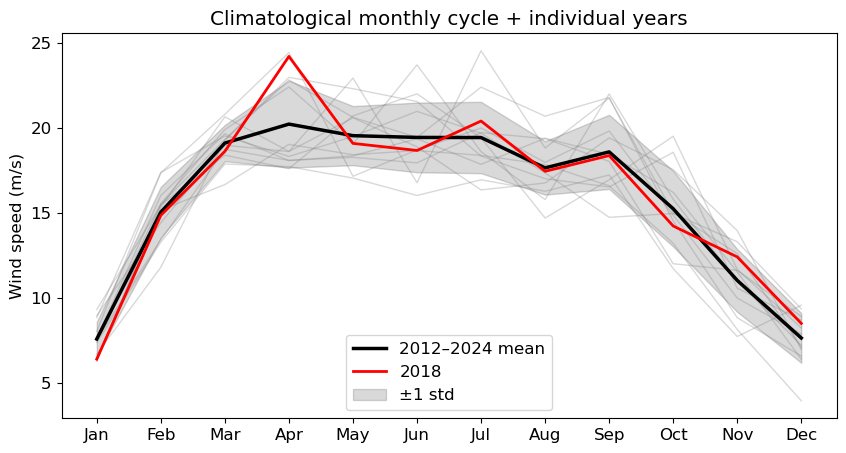

In [32]:
fig, ax = plt.subplots(figsize=(10,5))

# Plot individual years (faint)
for yr in ws_2d.year.values:
    ax.plot(
        ws_2d.month,
        ws_2d.sel(year=yr),
        color='gray',
        alpha=0.3,
        linewidth=1
    )

# Plot climatology (bold)
ax.plot(
    ws_clim.month,
    ws_clim,
    color='k',
    linewidth=2.5,
    label='2012–2024 mean'
)

ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])

ax.set_ylabel('Wind speed (m/s)')
ax.set_title('Climatological monthly cycle + individual years')

ax.plot(
    ws_2d.month,
    ws_2d.sel(year=2018),
    color='red',
    linewidth=2,
    label='2018'
)

ax.fill_between(
    ws_clim.month,
    ws_clim - ws_std,
    ws_clim + ws_std,
    color='k',
    alpha=0.15,
    label='±1 std'
)

ax.legend()
plt.show()

### Wind Direction Analysis 

In [52]:
# need to split into u and v components 

theta = np.deg2rad(ds.wind_dir)

ds = ds.assign(
    u = -ds.wind_speed * np.sin(theta),  # east-west
    v = -ds.wind_speed * np.cos(theta)   # north-south
)

In [53]:
ds_mon = ds.resample(time='MS').mean()

In [54]:
u_clim = ds_mon.u.groupby('time.month').mean('time')
v_clim = ds_mon.v.groupby('time.month').mean('time')

In [55]:
u_anom = ds_mon.u.groupby('time.month') - u_clim
v_anom = ds_mon.v.groupby('time.month') - v_clim

In [56]:
season_year = xr.where(
    ds_mon.time.dt.month == 12,
    ds_mon.time.dt.year + 1,
    ds_mon.time.dt.year
)

u_anom = u_anom.assign_coords(season_year=("time", season_year.data))
v_anom = v_anom.assign_coords(season_year=("time", season_year.data))

DJF_u = u_anom.where(u_anom.time.dt.season == 'DJF', drop=True).groupby('season_year').mean()
DJF_v = v_anom.where(v_anom.time.dt.season == 'DJF', drop=True).groupby('season_year').mean()

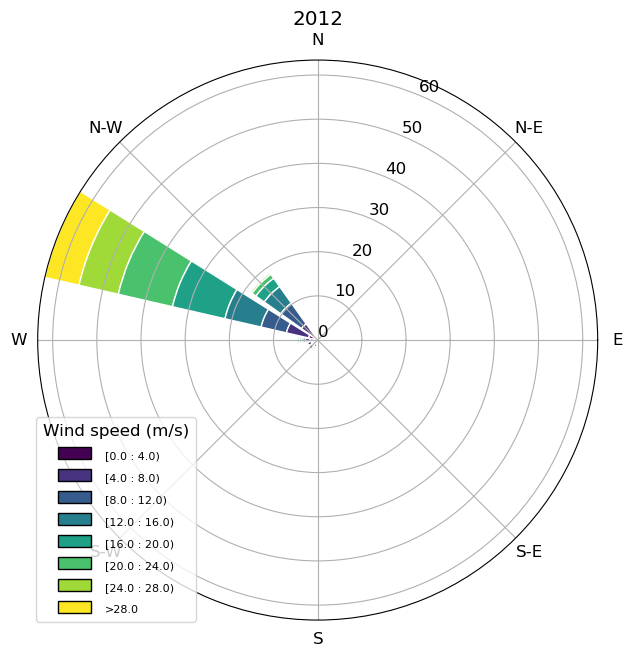

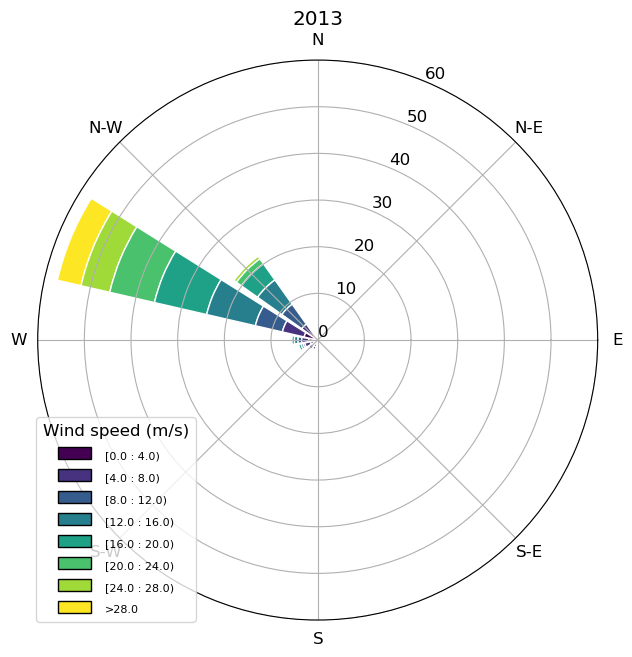

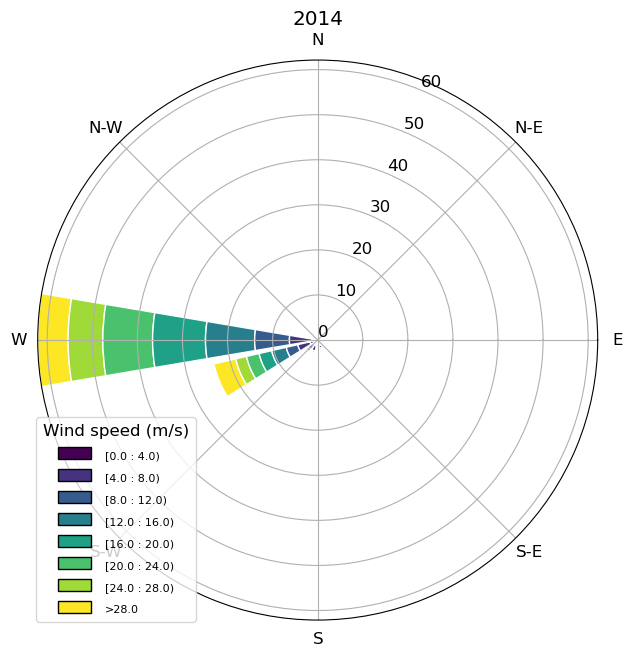

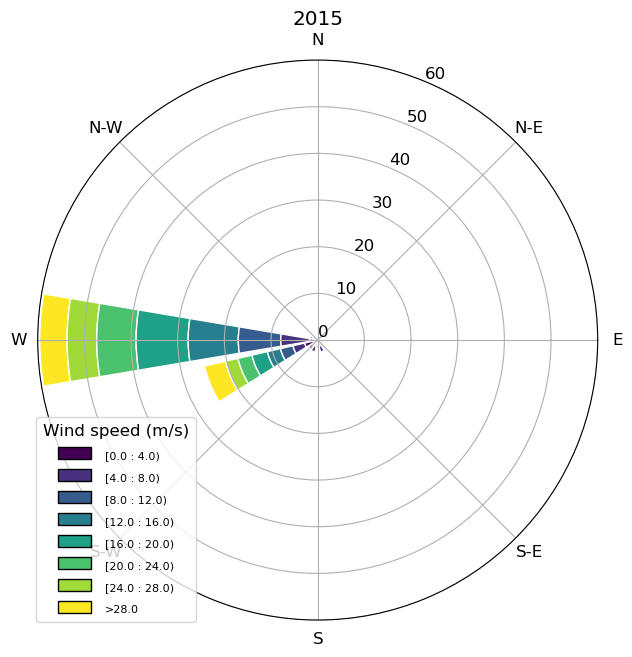

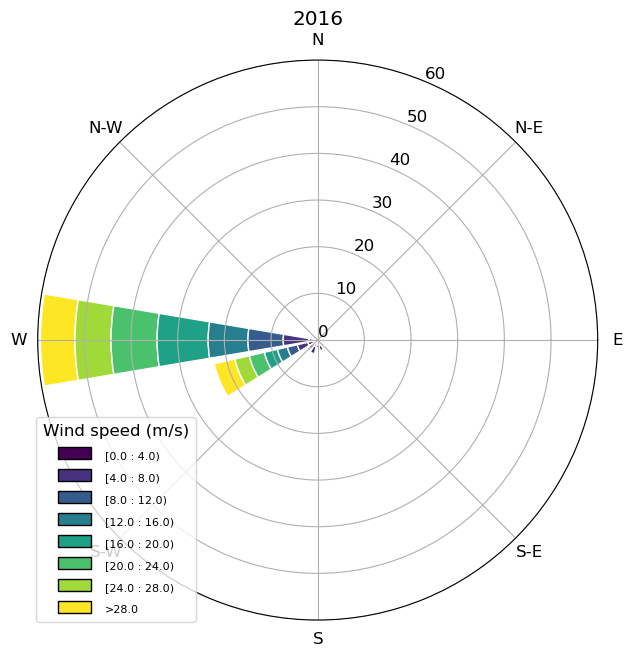

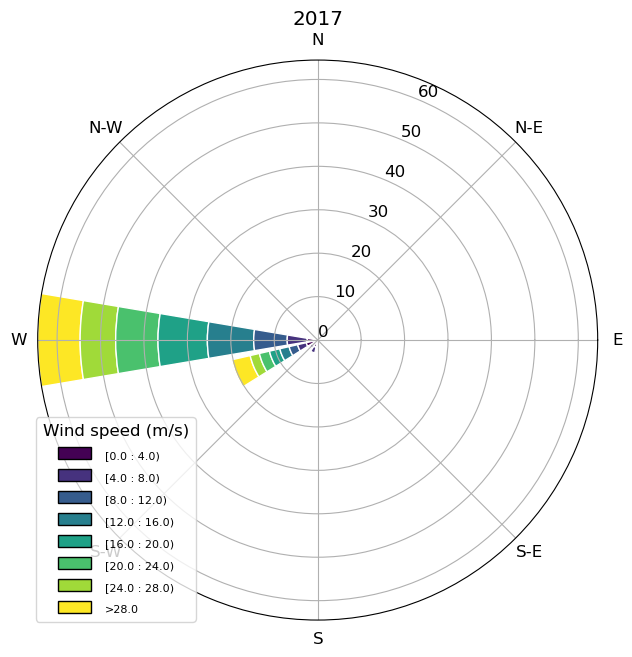

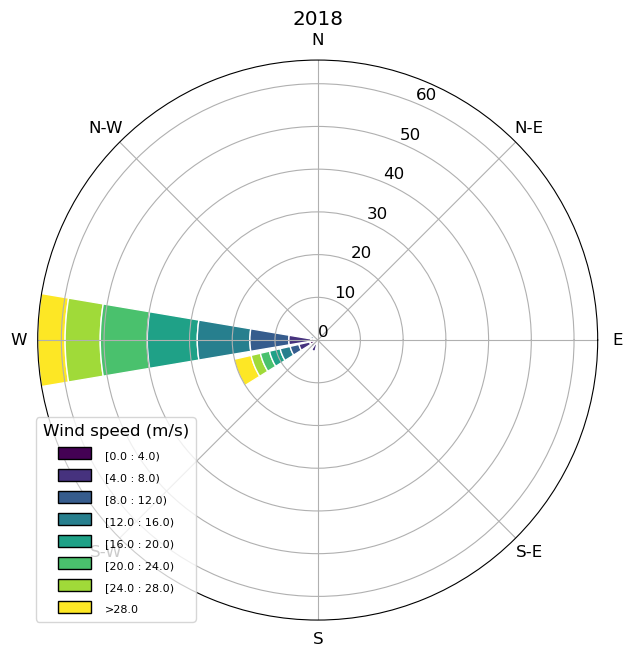

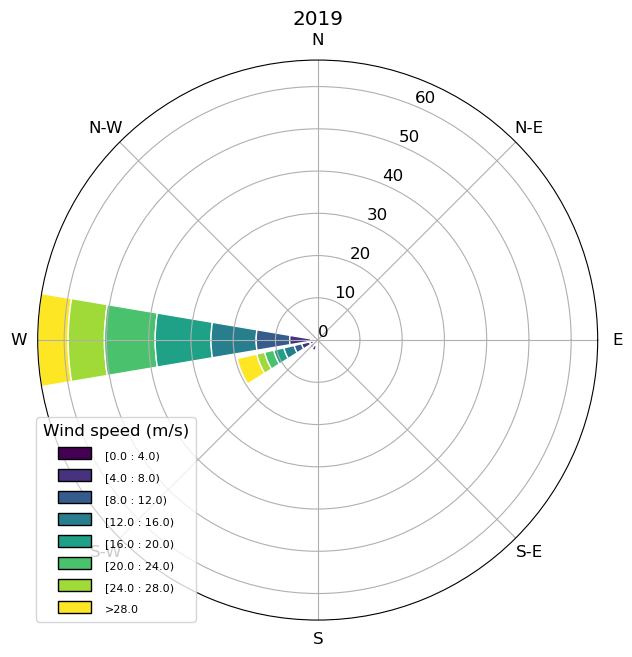

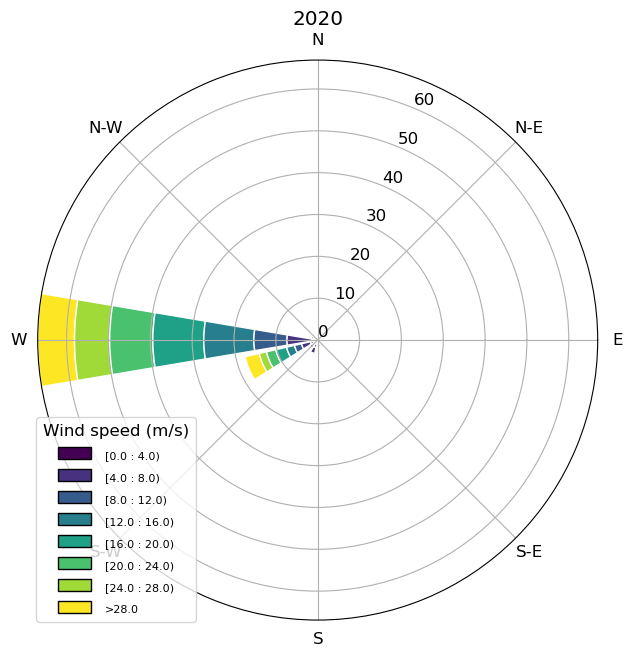

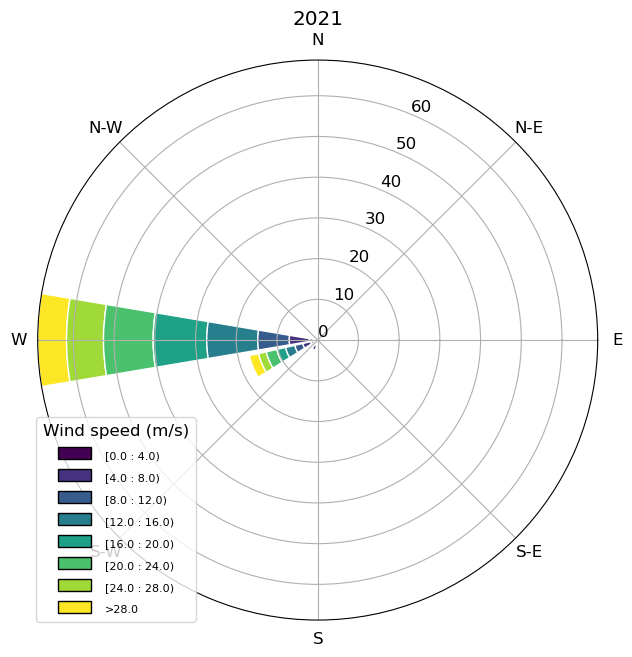

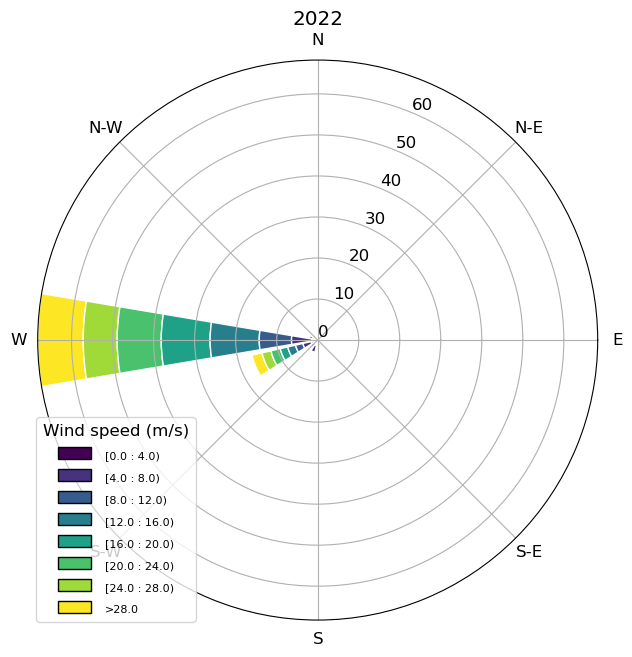

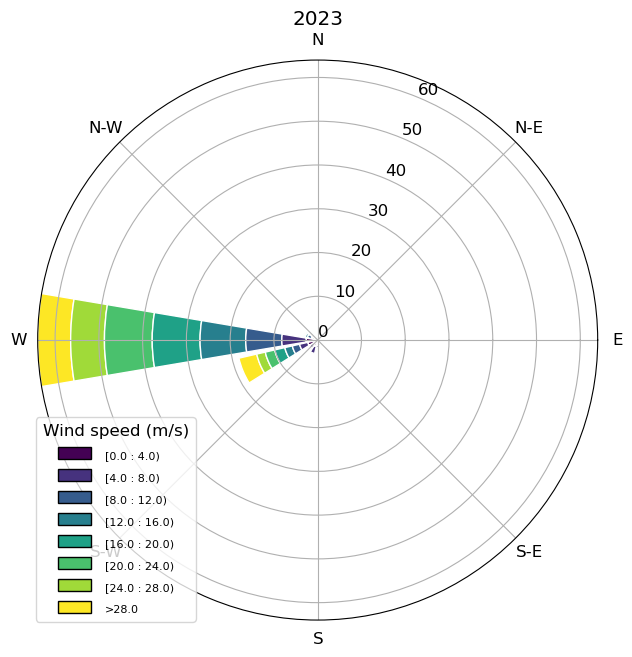

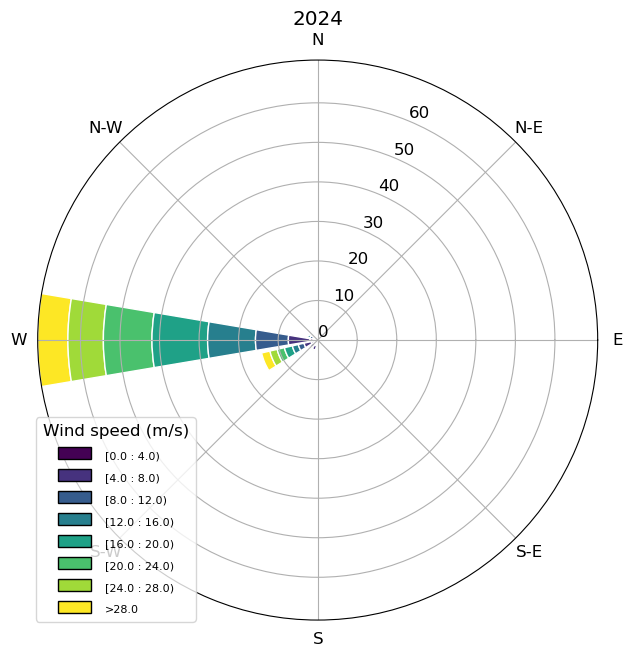

In [90]:
for i in range(len(year)):
    wd = ds['wind_dir'].sel(time=str(year[i])).values
    ws = ds['wind_speed'].sel(time=str(year[i])).values

    mask = np.isfinite(wd) & np.isfinite(ws)
    wd = wd[mask]
    ws = ws[mask]

    bins = [0, 4, 8, 12, 16, 20, 24, 28]

    fig = plt.figure(figsize=(7,7))
    ax = WindroseAxes.from_ax(fig=fig)

    ax.bar(
        wd,
        ws,
        bins=bins,
        nsector=16,
        normed=True,
        opening=0.85,
        edgecolor='white'
    )
    y_ticks = range(0,70,10)
    ax.set_rgrids(y_ticks, y_ticks)

    ax.set_title(f'{year[i]}')
    ax.set_legend(title='Wind speed (m/s)')
    plt.show()

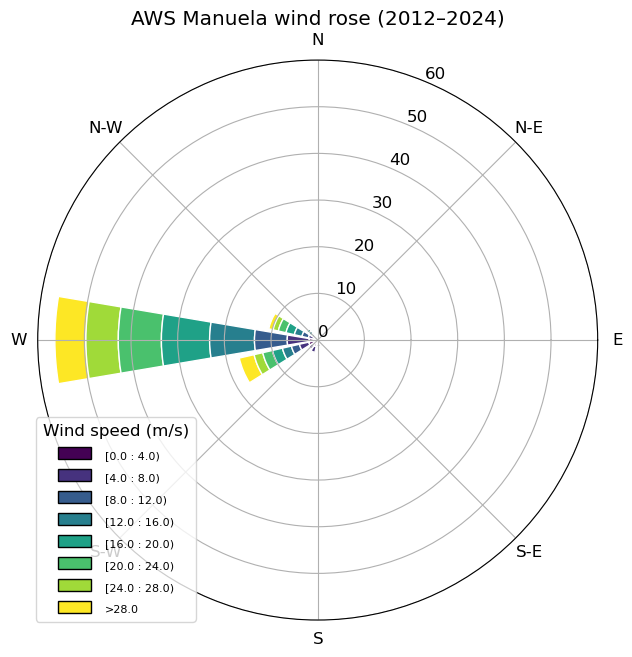

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

wd = ds['wind_dir'].values
ws = ds['wind_speed'].values

mask = np.isfinite(wd) & np.isfinite(ws)
wd = wd[mask]
ws = ws[mask]

bins = [0, 4, 8, 12, 16, 20, 24, 28]

fig = plt.figure(figsize=(7,7))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(
    wd,
    ws,
    bins=bins,
    nsector=16,
    normed=True,
    opening=0.85,
    edgecolor='white'
)
y_ticks = range(0,70,10)
ax.set_rgrids(y_ticks, y_ticks)

ax.set_title('AWS Manuela wind rose (2012–2024)')
ax.set_legend(title='Wind speed (m/s)')
plt.show()

In [79]:
wd = ds['wind_dir'].values
ws = ds['wind_speed'].values

mask = np.isfinite(wd) & np.isfinite(ws)
wd = wd[mask]
ws = ws[mask]

ax.bar(wd, ws, normed=True, nsector=16)
table = ax._info["table"]
wd_freq = np.sum(table, axis=0)

[Text(0, 0, 'N'),
 Text(1, 0, ''),
 Text(2, 0, 'N-E'),
 Text(3, 0, ''),
 Text(4, 0, 'E'),
 Text(5, 0, ''),
 Text(6, 0, 'S-E'),
 Text(7, 0, ''),
 Text(8, 0, 'S'),
 Text(9, 0, ''),
 Text(10, 0, 'S-W'),
 Text(11, 0, ''),
 Text(12, 0, 'W'),
 Text(13, 0, ''),
 Text(14, 0, 'N-W'),
 Text(15, 0, '')]

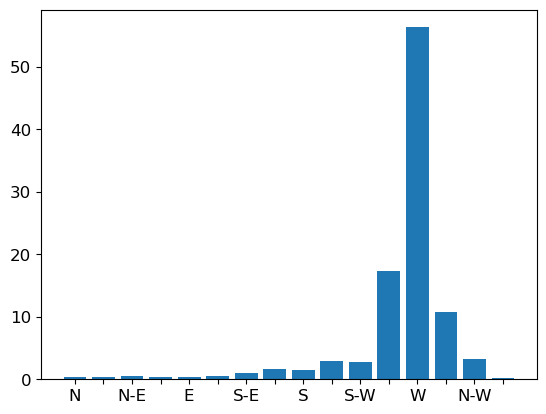

In [82]:
direction = ax._info["dir"]
wd_freq = np.sum(table, axis=0)

plt.bar(np.arange(16), wd_freq, align="center")
xlabels = (
    "N",
    "",
    "N-E",
    "",
    "E",
    "",
    "S-E",
    "",
    "S",
    "",
    "S-W",
    "",
    "W",
    "",
    "N-W",
    "",
)
xticks = np.arange(16)
plt.gca().set_xticks(xticks)
plt.gca().set_xticklabels(xlabels)
